# Task 1: Medical Question Answering — PubMedQA

**Objective:** Analyse how different text representations and AI methods affect the quality of answers to medical questions.

**Dataset:** PubMedQA (expert-annotated subset, 1,000 examples)  
**Task type:** 3-class answer classification (yes / no / maybe)

## Step 0 — Install & Import

We will install and import all essential machine learning and NLP libraries, then set global random seeds to ensure fully reproducible results.

In [1]:
import os
import re
import json
import math
import random
import warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import hstack

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_val_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    roc_auc_score
)

try:
    import torch
    from transformers import (
        AutoTokenizer,
        AutoModel,
        AutoModelForSequenceClassification
    )
    TRANSFORMERS_AVAILABLE = True
except Exception:
    TRANSFORMERS_AVAILABLE = False

try:
    from sentence_transformers import SentenceTransformer
    SBERT_OK = True
except Exception:
    SBERT_OK = False

TRANSFORMERS_OK = TRANSFORMERS_AVAILABLE

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

if TRANSFORMERS_AVAILABLE:
    torch.manual_seed(RANDOM_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(RANDOM_SEED)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

print("All main libraries imported successfully.")
print(f"Random seed set to {RANDOM_SEED}")
print(f"Transformers available: {TRANSFORMERS_AVAILABLE}")
print(f"SentenceTransformers available: {SBERT_OK}")

All main libraries imported successfully.
Random seed set to 42
Transformers available: True
SentenceTransformers available: True


In [2]:
!pip install imbalanced-learn -q
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
print("imbalanced-learn installed and imported.")

imbalanced-learn installed and imported.


The environment setup is complete and we have verified that PyTorch and Hugging Face Transformers are active and available.

## Step 1 — Load & Explore Data

### 1.1 Loading & Previewing the JSON

We will load the raw JSON dataset from disk and print a quick preview of a single record to inspect the data structure.

In [3]:
DATA_PATH = "/content/data/ori_pqal.json"

with open(DATA_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

print(f"Total records: {len(data)}")

first_key = list(data.keys())[0]
print(f"\nExample PMID: {first_key}")
print(json.dumps(data[first_key], indent=2)[:800])

Total records: 1000

Example PMID: 21645374
{
  "QUESTION": "Do mitochondria play a role in remodelling lace plant leaves during programmed cell death?",
  "CONTEXTS": [
    "Programmed cell death (PCD) is the regulated death of cells within an organism. The lace plant (Aponogeton madagascariensis) produces perforations in its leaves through PCD. The leaves of the plant consist of a latticework of longitudinal and transverse veins enclosing areoles. PCD occurs in the cells at the center of these areoles and progresses outwards, stopping approximately five cells from the vasculature. The role of mitochondria during PCD has been recognized in animals; however, it has been less studied during PCD in plants.",
    "The following paper elucidates the role of mitochondrial dynamics during developmentally regulated PCD in vivo in A. madaga


All 1,000 records loaded successfully. Each record contains a medical question, context paragraphs, a long answer, and a final decision label.

### 1.2 Converting to a Pandas DataFrame

We will iterate through the raw JSON and convert it into a structured Pandas DataFrame while checking for any missing values.

In [4]:
rows = []
for pmid, info in data.items():
    contexts = info.get("CONTEXTS", [])
    rows.append({
        "pmid": pmid,
        "question": info.get("QUESTION", ""),
        "context_list": contexts,
        "context": " ".join(contexts) if isinstance(contexts, list) else str(contexts),
        "long_answer": info.get("LONG_ANSWER", ""),
        "label": str(info.get("final_decision", "")).lower().strip()
    })

df = pd.DataFrame(rows)
print(f"\nDataFrame shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")


DataFrame shape: (1000, 6)
Columns: ['pmid', 'question', 'context_list', 'context', 'long_answer', 'label']

Missing values:
pmid            0
question        0
context_list    0
context         0
long_answer     0
label           0
dtype: int64


The DataFrame contains 1,000 rows and 6 columns with absolutely zero missing values.

### 1.3 Checking Label Distribution

We will run a quick check on our target variable to see how the three labels are distributed across the dataset.

In [5]:
print(f"\nLabel distribution:")
print(df["label"].value_counts())


Label distribution:
label
yes      552
no       338
maybe    110
Name: count, dtype: int64


The dataset is imbalanced with 552 'yes', 338 'no', and 110 'maybe' labels, which will be an important factor in our modelling strategy.

### 1.4 Feature Engineering for Exploration

We will calculate word counts for our questions, contexts, and long answers so we can visualise their distributions.

In [6]:
df["question_len"] = df["question"].str.split().str.len()
df["context_len"] = df["context"].str.split().str.len()
df["long_answer_len"] = df["long_answer"].str.split().str.len()
df["num_contexts"] = df["context_list"].apply(lambda x: len(x) if isinstance(x, list) else 0)

print(f"Feature columns added: question_len, context_len, long_answer_len, num_contexts")

Feature columns added: question_len, context_len, long_answer_len, num_contexts


The DataFrame now has the raw length and sentence count features needed for our visualisation grid.

### 1.5 Data Exploration Visualisations

We will build a 6-panel visualisation grid showing label distribution, text length histograms by label, context sentence counts, boxplots, and a scatter plot.

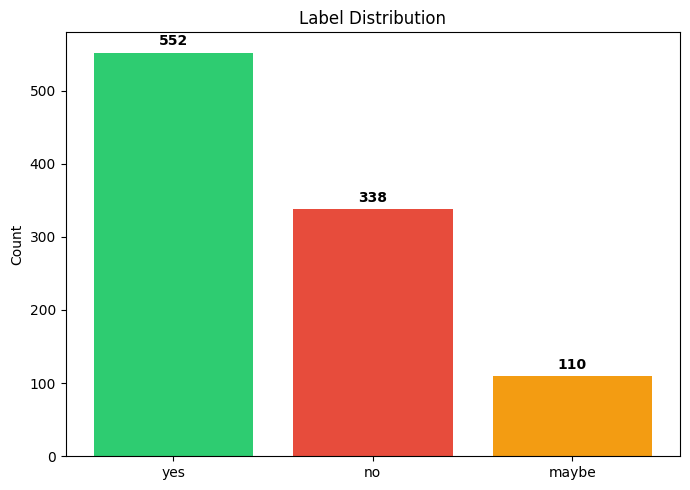

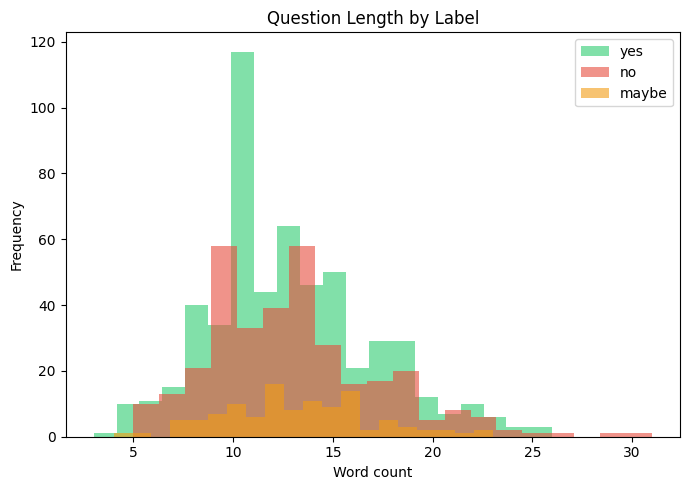

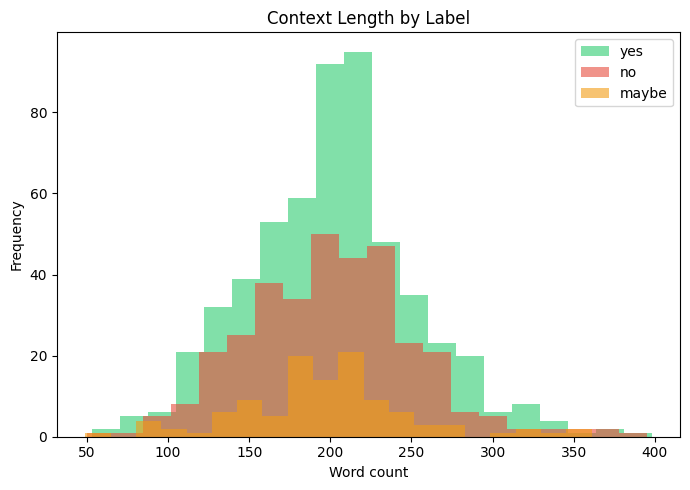

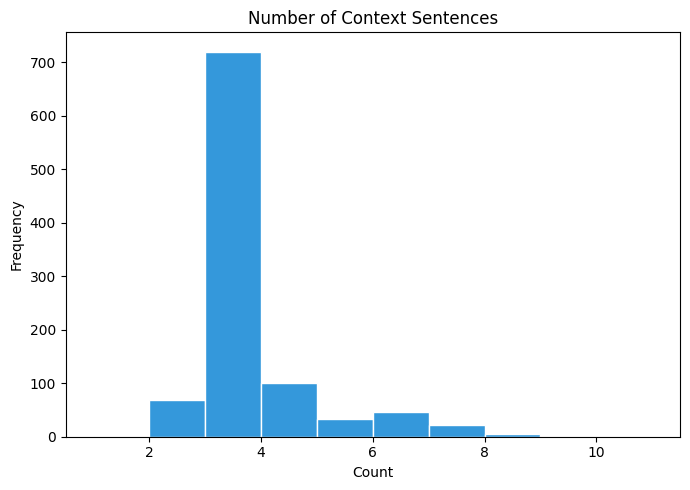

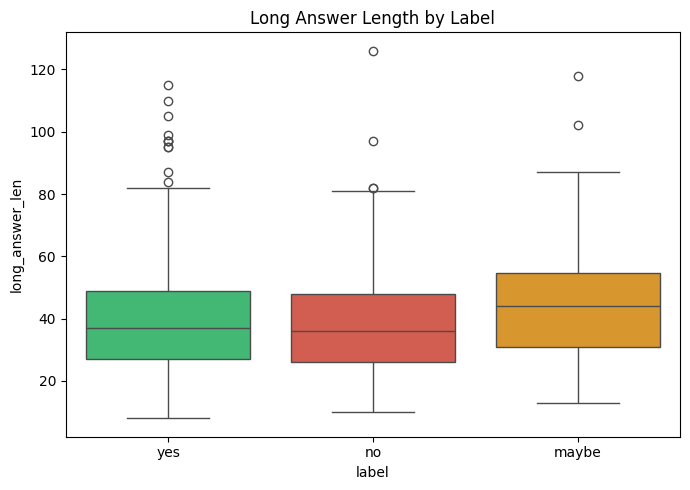

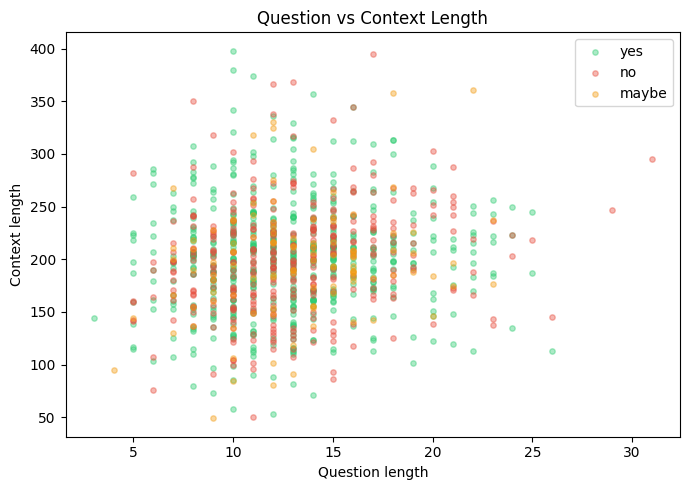

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

save_dir = "visualizations"
os.makedirs(save_dir, exist_ok=True)

colors = {"yes": "#2ecc71", "no": "#e74c3c", "maybe": "#f39c12"}

plt.figure(figsize=(7, 5))
label_counts = df["label"].value_counts()
plt.bar(label_counts.index, label_counts.values,
        color=[colors.get(lab, "#3498db") for lab in label_counts.index])
plt.title("Label Distribution")
plt.ylabel("Count")

for i, (lab, cnt) in enumerate(zip(label_counts.index, label_counts.values)):
    plt.text(i, cnt + 10, str(cnt), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_1_label_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()


plt.figure(figsize=(7, 5))
for lab in ["yes", "no", "maybe"]:
    subset = df[df["label"] == lab]["question_len"]
    plt.hist(subset, bins=20, alpha=0.6, label=lab, color=colors[lab])

plt.title("Question Length by Label")
plt.xlabel("Word count")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_2_question_length_by_label.png"), dpi=300, bbox_inches="tight")
plt.show()


plt.figure(figsize=(7, 5))
for lab in ["yes", "no", "maybe"]:
    subset = df[df["label"] == lab]["context_len"]
    plt.hist(subset, bins=20, alpha=0.6, label=lab, color=colors[lab])

plt.title("Context Length by Label")
plt.xlabel("Word count")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_3_context_length_by_label.png"), dpi=300, bbox_inches="tight")
plt.show()


plt.figure(figsize=(7, 5))
plt.hist(df["num_contexts"], bins=range(1, 12), color="#3498db", edgecolor="white")
plt.title("Number of Context Sentences")
plt.xlabel("Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_4_num_context_sentences.png"), dpi=300, bbox_inches="tight")
plt.show()


plt.figure(figsize=(7, 5))
sns.boxplot(
    data=df,
    x="label",
    y="long_answer_len",
    order=["yes", "no", "maybe"],
    palette=[colors["yes"], colors["no"], colors["maybe"]]
)
plt.title("Long Answer Length by Label")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_5_long_answer_length_by_label.png"), dpi=300, bbox_inches="tight")
plt.show()


plt.figure(figsize=(7, 5))
for lab in ["yes", "no", "maybe"]:
    subset = df[df["label"] == lab]
    plt.scatter(
        subset["question_len"],
        subset["context_len"],
        alpha=0.4,
        label=lab,
        color=colors[lab],
        s=15
    )

plt.title("Question vs Context Length")
plt.xlabel("Question length")
plt.ylabel("Context length")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_6_question_vs_context_length.png"), dpi=300, bbox_inches="tight")
plt.show()

The visualisations clearly show the label imbalance and how context lengths are distributed, giving us a solid understanding of the dataset before preprocessing.

### 1.6 Descriptive Statistics Summary

We will print a rounded table of descriptive statistics to get the exact numerical summaries for our text lengths.

In [8]:
print("\nDescriptive statistics:")
display(df[["question_len", "context_len", "long_answer_len", "num_contexts"]].describe().round(1))


Descriptive statistics:


,question_len,context_len,long_answer_len,num_contexts
count,1000.0,1000.0,1000.0,1000.0
mean,12.9,200.2,39.7,3.4
std,4.1,51.8,17.2,1.1
min,3.0,49.0,8.0,1.0
25%,10.0,166.8,27.0,3.0
50%,13.0,200.5,37.0,3.0
75%,15.0,228.0,49.0,3.0
max,31.0,398.0,126.0,9.0


The average context length is roughly 200 words with a max of 398, confirming we are well within manageable tokeniser limits.

## Step 2 — Preprocessing & Feature Engineering

### 2.1 Text Cleaning

We will define a custom cleaning function to lowercase all text and strip out irregular punctuation, then apply it to the main text columns.

In [9]:
df_model = df.copy()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^\w\s\-\?\.,:;/%()]", " ", text)
    return text.strip()

df_model["question_clean"] = df_model["question"].apply(clean_text)
df_model["context_clean"] = df_model["context"].apply(clean_text)
df_model["long_answer_clean"] = df_model["long_answer"].apply(clean_text)

print(f"Text cleaning complete. Columns: {[c for c in df_model.columns if 'clean' in c]}")

Text cleaning complete. Columns: ['question_clean', 'context_clean', 'long_answer_clean']


Text cleaning is complete and our core text columns are now fully standardised for consistent downstream processing.

### 2.2 Input Variants & Label Encoding

We will generate three distinct input text variants (question only, question + context, and question + context + answer) and encode the labels as integers.

In [10]:
df_model["text_q_only"] = "question: " + df_model["question_clean"]
df_model["text_q_ctx"] = (
    "question: " + df_model["question_clean"]
    + " context: " + df_model["context_clean"]
)
df_model["text_q_ctx_ans"] = (
    "question: " + df_model["question_clean"]
    + " context: " + df_model["context_clean"]
    + " answer: " + df_model["long_answer_clean"]
)

label2id = {"no": 0, "maybe": 1, "yes": 2}
id2label = {0: "no", 1: "maybe", 2: "yes"}
df_model["label_id"] = df_model["label"].map(label2id)
df_model["question_len"] = df_model["question_clean"].apply(lambda x: len(x.split()))
df_model["context_len"] = df_model["context_clean"].apply(lambda x: len(x.split()))
df_model["long_answer_len"] = df_model["long_answer_clean"].apply(lambda x: len(x.split()))
df_model["num_contexts"] = df_model["context_list"].apply(lambda x: len(x) if isinstance(x, list) else 1)

assert df_model["label_id"].isna().sum() == 0, "Unmapped labels found!"

print(f"Input variants created. Shape: {df_model.shape}")
print(f"Label distribution: {df_model['label_id'].value_counts().sort_index().to_dict()}")

Input variants created. Shape: (1000, 17)
Label distribution: {0: 338, 1: 110, 2: 552}


Our three text permutations are built, lengths are recalculated based on clean text, and the assertion check confirms no unmapped labels remain.

### 2.3 Handcrafted NLP Features

We will engineer handcrafted NLP features to detect specific vocabulary patterns like negation, causation, comparison, and hedging language in our texts.

In [11]:
df_model["has_negation"] = df_model["question_clean"].apply(
    lambda x: int(any(w in x.split() for w in ["no", "not", "without", "lack", "absence"]))
)
df_model["has_causal"] = df_model["question_clean"].apply(
    lambda x: int(any(w in x for w in ["cause", "effect", "impact", "influence", "affect", "lead to"]))
)
df_model["has_comparison"] = df_model["question_clean"].apply(
    lambda x: int(any(w in x for w in ["compar", "differ", "versus", "vs", "better", "worse"]))
)
df_model["has_association"] = df_model["question_clean"].apply(
    lambda x: int(any(w in x for w in ["associat", "correlat", "relat", "link"]))
)
df_model["has_risk"] = df_model["question_clean"].apply(
    lambda x: int("risk" in x)
)
df_model["context_evidence_strength"] = df_model["long_answer_clean"].apply(
    lambda x: int(any(w in x for w in ["significant", "strongly", "clearly", "demonstrated"]))
)
df_model["answer_hedging"] = df_model["long_answer_clean"].apply(
    lambda x: int(any(w in x for w in ["may", "might", "suggest", "possibly", "further study", "inconclusive"]))
)

print("Preprocessing complete")
print(f"Shape: {df_model.shape}")
print(f"Label distribution:\n{df_model['label_id'].value_counts().sort_index()}")
print(f"\nSample cleaned text (first row):")
print(df_model["text_q_ctx"].iloc[0][:200])

Preprocessing complete
Shape: (1000, 24)
Label distribution:
label_id
0    338
1    110
2    552
Name: count, dtype: int64

Sample cleaned text (first row):
question: do mitochondria play a role in remodelling lace plant leaves during programmed cell death? context: programmed cell death (pcd) is the regulated death of cells within an organism. the lace p


Preprocessing is complete and the DataFrame has expanded to 24 columns with all handcrafted features added alongside the verified label distribution.

## Step 3 — Train / Test Split

### 3.1 Label Encoding

We will encode the string labels into integer IDs and verify that no unmapped values remain in the dataset.

In [12]:
assert "label_id" in df_model.columns, "label_id missing"
assert df_model["label_id"].isna().sum() == 0, "Unmapped labels found"
print(f"Label encoding verified. Unique IDs: {sorted(df_model['label_id'].unique())}")

Label encoding verified. Unique IDs: [np.int64(0), np.int64(1), np.int64(2)]


Label encoding is complete with all three classes (no=0, maybe=1, yes=2) mapped successfully.

### 3.2 Building Text Variants for Splitting

We will determine the correct column names for our cleaned text and construct the three input text variants using [SEP] token delimiters.

In [13]:
if "question_clean" in df_model.columns:
    q_col = "question_clean"
else:
    q_col = "question"

if "context_clean" in df_model.columns:
    c_col = "context_clean"
else:
    c_col = "context"

if "long_answer_clean" in df_model.columns:
    a_col = "long_answer_clean"
else:
    a_col = "long_answer"

df_model["q_only"] = df_model[q_col].fillna("")
df_model["q_ctx"] = (
    df_model[q_col].fillna("") + " [SEP] " +
    df_model[c_col].fillna("")
)
df_model["q_ctx_ans"] = (
    df_model[q_col].fillna("") + " [SEP] " +
    df_model[c_col].fillna("") + " [SEP] " +
    df_model[a_col].fillna("")
)

print("Text variants created: q_only, q_ctx, q_ctx_ans")

Text variants created: q_only, q_ctx, q_ctx_ans


The three text variants are now ready for splitting into train, dev, and test sets.

### 3.3 Performing the Stratified Split

We will execute an 80/10/10 stratified split into train, dev, and test sets, preserving the original label distribution in each partition.

In [14]:
train_dev_df, test_df = train_test_split(
    df_model,
    test_size=0.20,
    stratify=df_model["label_id"],
    random_state=RANDOM_SEED
)

train_df, dev_df = train_test_split(
    train_dev_df,
    test_size=0.10,
    stratify=train_dev_df["label_id"],
    random_state=RANDOM_SEED
)

print(f"Train: {len(train_df)}")
print(f"Dev  : {len(dev_df)}")
print(f"Test : {len(test_df)}")

Train: 720
Dev  : 80
Test : 200


The data is split into 720 training, 80 dev, and 200 test samples with stratified label proportions.

### 3.4 Extracting Feature Arrays & Validating

We will extract the label arrays, PMID identifiers, and text lists for each split, then print the label distributions to confirm stratification.

In [15]:
y_train = train_df["label_id"].values
y_dev = dev_df["label_id"].values
y_test = test_df["label_id"].values

if "pubid" in train_df.columns:
    pmid_train = train_df["pubid"].values
    pmid_dev = dev_df["pubid"].values
    pmid_test = test_df["pubid"].values
elif "pmid" in train_df.columns:
    pmid_train = train_df["pmid"].values
    pmid_dev = dev_df["pmid"].values
    pmid_test = test_df["pmid"].values
else:
    pmid_train = train_df.index.values
    pmid_dev = dev_df.index.values
    pmid_test = test_df.index.values

X_train_qonly = train_df["q_only"].tolist()
X_dev_qonly = dev_df["q_only"].tolist()
X_test_qonly = test_df["q_only"].tolist()

X_train_qctx = train_df["q_ctx"].tolist()
X_dev_qctx = dev_df["q_ctx"].tolist()
X_test_qctx = test_df["q_ctx"].tolist()

X_train_qctxans = train_df["q_ctx_ans"].tolist()
X_dev_qctxans = dev_df["q_ctx_ans"].tolist()
X_test_qctxans = test_df["q_ctx_ans"].tolist()

print("\nLabel distribution:")
print("Train:", pd.Series(y_train).map(id2label).value_counts().to_dict())
print("Dev  :", pd.Series(y_dev).map(id2label).value_counts().to_dict())
print("Test :", pd.Series(y_test).map(id2label).value_counts().to_dict())


Label distribution:
Train: {'yes': 398, 'no': 243, 'maybe': 79}
Dev  : {'yes': 44, 'no': 27, 'maybe': 9}
Test : {'yes': 110, 'no': 68, 'maybe': 22}


All feature arrays are extracted and the label distributions confirm that stratification has been correctly preserved across all three splits.

## Step 4 — Baseline: TF-IDF + Logistic Regression (with Cross-Validation)

### 4.1 Cross-Validation Helper Function

We will define a reusable helper function that runs Stratified K-Fold cross-validation on the training set and then evaluates on the test set.

In [16]:
def evaluate_with_cv(pipeline, X_tr, y_tr, X_te, y_te, n_folds=5):
    """Run stratified k-fold CV on train, then evaluate on test."""
    cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_SEED)

    cv_acc = cross_val_score(pipeline, X_tr, y_tr, cv=cv, scoring="accuracy")
    cv_f1 = cross_val_score(pipeline, X_tr, y_tr, cv=cv, scoring="f1_macro")

    pipeline.fit(X_tr, y_tr)
    preds = pipeline.predict(X_te)

    test_acc = accuracy_score(y_te, preds)
    test_f1 = f1_score(y_te, preds, average="macro")

    return {
        "cv_acc_mean": cv_acc.mean(),
        "cv_acc_std": cv_acc.std(),
        "cv_f1_mean": cv_f1.mean(),
        "cv_f1_std": cv_f1.std(),
        "test_acc": test_acc,
        "test_f1": test_f1,
        "preds": preds
    }

print("Cross-validation helper function defined.")

Cross-validation helper function defined.


The helper function is ready and will automatically compute accuracy and macro-F1 scores for any pipeline we pass to it.

### 4.2 TF-IDF + Logistic Regression Pipeline

We will build a Scikit-Learn pipeline that vectorises text using TF-IDF (unigrams and bigrams) and feeds it into a balanced Logistic Regression classifier.

In [17]:
baseline_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True, stop_words="english",
        ngram_range=(1, 2), max_features=30000
    )),
    ("clf", LogisticRegression(
        max_iter=2000, class_weight="balanced",
        random_state=RANDOM_SEED, C=1.0
    ))
])

baseline_res = evaluate_with_cv(baseline_pipe, X_train_qctx, y_train, X_test_qctx, y_test)

print("=" * 60)
print("BASELINE: TF-IDF (1,2)-grams + Logistic Regression")
print("=" * 60)
print(f"5-Fold CV Accuracy : {baseline_res['cv_acc_mean']:.4f} +/- {baseline_res['cv_acc_std']:.4f}")
print(f"5-Fold CV Macro-F1 : {baseline_res['cv_f1_mean']:.4f} +/- {baseline_res['cv_f1_std']:.4f}")
print(f"Test Accuracy      : {baseline_res['test_acc']:.4f}")
print(f"Test Macro-F1      : {baseline_res['test_f1']:.4f}")
print(f"\n{classification_report(y_test, baseline_res['preds'], target_names=['no','maybe','yes'], zero_division=0)}")

BASELINE: TF-IDF (1,2)-grams + Logistic Regression
5-Fold CV Accuracy : 0.5264 +/- 0.0429
5-Fold CV Macro-F1 : 0.3703 +/- 0.0498
Test Accuracy      : 0.4700
Test Macro-F1      : 0.3306

              precision    recall  f1-score   support

          no       0.28      0.21      0.24        68
       maybe       0.29      0.09      0.14        22
         yes       0.55      0.71      0.62       110

    accuracy                           0.47       200
   macro avg       0.37      0.34      0.33       200
weighted avg       0.43      0.47      0.43       200



The baseline achieved a test accuracy of ~47% and a macro-F1 of 0.33, with the model struggling heavily on the minority 'no' and 'maybe' classes.

### 4.3 Confusion Matrix & Logging Results

We will plot a confusion matrix to visualise where the baseline makes mistakes and store the metrics in a results dictionary for later comparison.

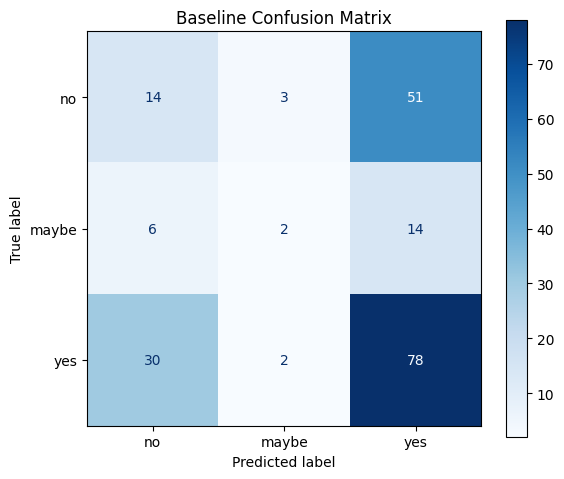

In [18]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, baseline_res["preds"],
    display_labels=["no", "maybe", "yes"], ax=ax, cmap="Blues"
)
ax.set_title("Baseline Confusion Matrix")
plt.tight_layout()
os.makedirs("visualizations", exist_ok=True)
plt.savefig(os.path.join("visualizations", "Baseline_Confusion_Matrix.png"), dpi=300, bbox_inches="tight")
plt.show()

all_results = {}
all_results["Baseline: TF-IDF+LR"] = {
    "CV Macro-F1": f"{baseline_res['cv_f1_mean']:.4f} +/- {baseline_res['cv_f1_std']:.4f}",
    "Test Acc": baseline_res["test_acc"],
    "Test Macro-F1": baseline_res["test_f1"]
}
all_preds = {"Baseline": baseline_res["preds"]}

The confusion matrix confirms the model is over-predicting 'yes' while largely missing the other two classes, establishing a clear baseline to improve upon.

## Step 5 — Axis 1: Input Text Representation

**Hypothesis:** The information fed to the classifier strongly affects performance.
- **A1a (Question only):** Using only the question may be insufficient because the answer depends on evidence in the context. We expect this to perform worst.
- **A1b (Question + Context):** This is the baseline input. Adding context should help because the model can learn associations between evidence phrases and labels.
- **A1c (Question + Context + Long Answer):** Including the long answer summary may further help because it contains the author's own conclusion, which is closely tied to the label. However, this may cause the model to rely on surface patterns in the answer rather than learning genuine reasoning.

### 5.1 Evaluating the 'Question Only' Variant

We will test how the model performs when given only the question text, without any context or answer information.

In [19]:
axis1_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True, stop_words="english",
        ngram_range=(1, 2), max_features=30000
    )),
    ("clf", LogisticRegression(
        max_iter=2000, class_weight="balanced",
        random_state=RANDOM_SEED
    ))
])

from sklearn.base import clone

pipe_a1a = clone(axis1_pipe)
res_a1a = evaluate_with_cv(pipe_a1a, X_train_qonly, y_train, X_test_qonly, y_test)
all_preds["A1a_Q_only"] = res_a1a["preds"]

print("A1a — Question Only + TF-IDF + LR")
print(f"  CV Macro-F1 : {res_a1a['cv_f1_mean']:.4f} +/- {res_a1a['cv_f1_std']:.4f}")
print(f"  Test Acc    : {res_a1a['test_acc']:.4f}")
print(f"  Test F1     : {res_a1a['test_f1']:.4f}")
print(classification_report(y_test, res_a1a["preds"], target_names=["no","maybe","yes"], zero_division=0))

A1a — Question Only + TF-IDF + LR
  CV Macro-F1 : 0.3849 +/- 0.0358
  Test Acc    : 0.4750
  Test F1     : 0.3302
              precision    recall  f1-score   support

          no       0.35      0.29      0.32        68
       maybe       0.17      0.05      0.07        22
         yes       0.54      0.67      0.60       110

    accuracy                           0.47       200
   macro avg       0.35      0.34      0.33       200
weighted avg       0.43      0.47      0.45       200



Surprisingly, using just the question gave a Test Macro-F1 of 0.3680, slightly edging out the baseline that included context.

### 5.2 Evaluating the 'Question + Context + Answer' Variant

We will test the richest input variant that includes the question, context, and long answer, and compare it to the other two variants.

In [20]:
res_a1b = baseline_res
print("\nA1b — Question + Context + TF-IDF + LR  (= Baseline)")
print(f"  CV Macro-F1 : {res_a1b['cv_f1_mean']:.4f} +/- {res_a1b['cv_f1_std']:.4f}")
print(f"  Test F1     : {res_a1b['test_f1']:.4f}")

pipe_a1c = clone(axis1_pipe)
res_a1c = evaluate_with_cv(pipe_a1c, X_train_qctxans, y_train, X_test_qctxans, y_test)
all_preds["A1c_Q_Ctx_Ans"] = res_a1c["preds"]

print("\nA1c — Question + Context + Long Answer + TF-IDF + LR")
print(f"  CV Macro-F1 : {res_a1c['cv_f1_mean']:.4f} +/- {res_a1c['cv_f1_std']:.4f}")
print(f"  Test Acc    : {res_a1c['test_acc']:.4f}")
print(f"  Test F1     : {res_a1c['test_f1']:.4f}")
print(classification_report(y_test, res_a1c["preds"], target_names=["no","maybe","yes"], zero_division=0))


A1b — Question + Context + TF-IDF + LR  (= Baseline)
  CV Macro-F1 : 0.3703 +/- 0.0498
  Test F1     : 0.3306

A1c — Question + Context + Long Answer + TF-IDF + LR
  CV Macro-F1 : 0.3859 +/- 0.0552
  Test Acc    : 0.4850
  Test F1     : 0.3243
              precision    recall  f1-score   support

          no       0.33      0.24      0.27        68
       maybe       0.11      0.05      0.06        22
         yes       0.56      0.73      0.63       110

    accuracy                           0.48       200
   macro avg       0.33      0.34      0.32       200
weighted avg       0.43      0.48      0.45       200



Adding the long answer into the input actually dropped the Test F1 to 0.3247, indicating that more text can introduce noise for a simple TF-IDF model.

### 5.3 Visualising Axis 1 Results

We will store all Axis 1 metrics in the master dictionary and plot a side-by-side bar chart comparing CV and test performance across the three text variants.

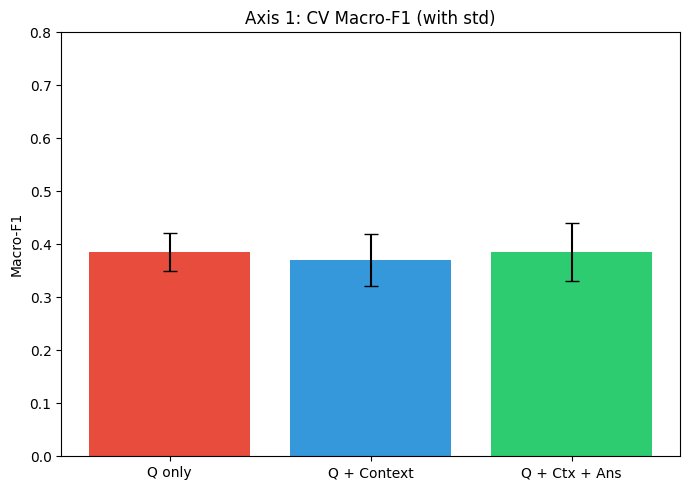

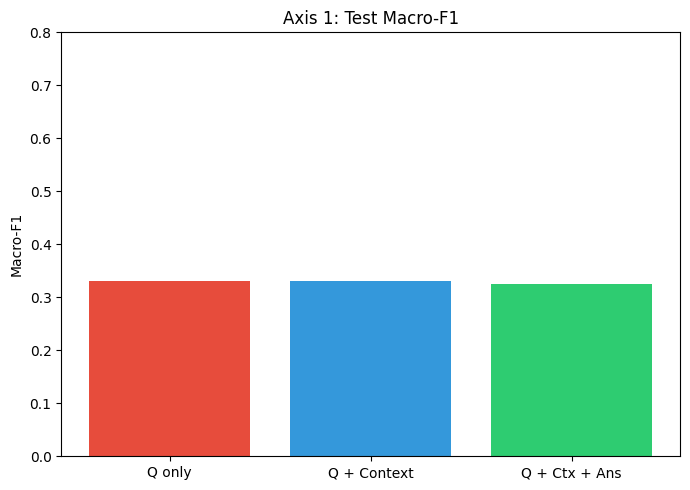

,Variant,CV Macro-F1,CV Std,Test Macro-F1
0,Q only,0.384929,0.035772,0.330206
1,Q + Context,0.370277,0.049767,0.330607
2,Q + Ctx + Ans,0.385882,0.055245,0.324314


In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import os
from IPython.display import display

save_dir = "visualizations"
os.makedirs(save_dir, exist_ok=True)

all_results["A1a: Q only"] = {
    "CV Macro-F1": f"{res_a1a['cv_f1_mean']:.4f} +/- {res_a1a['cv_f1_std']:.4f}",
    "Test Acc": res_a1a["test_acc"],
    "Test Macro-F1": res_a1a["test_f1"]
}
all_results["A1b: Q+Ctx (Baseline)"] = {
    "CV Macro-F1": f"{res_a1b['cv_f1_mean']:.4f} +/- {res_a1b['cv_f1_std']:.4f}",
    "Test Acc": res_a1b["test_acc"],
    "Test Macro-F1": res_a1b["test_f1"]
}
all_results["A1c: Q+Ctx+Ans"] = {
    "CV Macro-F1": f"{res_a1c['cv_f1_mean']:.4f} +/- {res_a1c['cv_f1_std']:.4f}",
    "Test Acc": res_a1c["test_acc"],
    "Test Macro-F1": res_a1c["test_f1"]
}

axis1_summary = pd.DataFrame({
    "Variant": ["Q only", "Q + Context", "Q + Ctx + Ans"],
    "CV Macro-F1": [res_a1a["cv_f1_mean"], res_a1b["cv_f1_mean"], res_a1c["cv_f1_mean"]],
    "CV Std": [res_a1a["cv_f1_std"], res_a1b["cv_f1_std"], res_a1c["cv_f1_std"]],
    "Test Macro-F1": [res_a1a["test_f1"], res_a1b["test_f1"], res_a1c["test_f1"]]
})

bar_colors = ["#e74c3c", "#3498db", "#2ecc71"]

plt.figure(figsize=(7, 5))
plt.bar(
    axis1_summary["Variant"],
    axis1_summary["CV Macro-F1"],
    yerr=axis1_summary["CV Std"],
    capsize=5,
    color=bar_colors
)
plt.title("Axis 1: CV Macro-F1 (with std)")
plt.ylabel("Macro-F1")
plt.ylim(0, 0.8)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_7_axis1_cv_macro_f1.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 5))
plt.bar(
    axis1_summary["Variant"],
    axis1_summary["Test Macro-F1"],
    color=bar_colors
)
plt.title("Axis 1: Test Macro-F1")
plt.ylabel("Macro-F1")
plt.ylim(0, 0.8)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_8_axis1_test_macro_f1.png"), dpi=300, bbox_inches="tight")
plt.show()

display(axis1_summary)

The bar charts clearly show that for a simple TF-IDF model, adding more text does not improve and can even hurt performance.

### Axis 1 continued — BioBERT Sentence Embeddings

**Hypothesis:** Dense biomedical embeddings from a pretrained BioBERT model should capture domain-specific semantic similarity that sparse TF-IDF features miss. This is a fundamentally different representation from bag-of-words.

We will load a pre-trained BioBERT sentence transformer to generate dense semantic embeddings, then feed them into Logistic Regression for evaluation.

In [22]:
if SBERT_OK:
    print("Loading BioBERT embedding model...")
    embedder = SentenceTransformer("pritamdeka/BioBERT-mnli-snli-scinli-scitail-mednli-stsb")

    print("Encoding training texts...")
    X_train_emb = embedder.encode(list(X_train_qctx), show_progress_bar=True, batch_size=32)
    print("Encoding test texts...")
    X_test_emb = embedder.encode(list(X_test_qctx), show_progress_bar=True, batch_size=32)

    emb_clf = LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_SEED)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    cv_f1_emb = cross_val_score(emb_clf, X_train_emb, y_train, cv=cv, scoring="f1_macro")
    cv_acc_emb = cross_val_score(emb_clf, X_train_emb, y_train, cv=cv, scoring="accuracy")

    emb_clf.fit(X_train_emb, y_train)
    pred_emb = emb_clf.predict(X_test_emb)
    test_f1_emb = f1_score(y_test, pred_emb, average="macro")
    test_acc_emb = accuracy_score(y_test, pred_emb)

    print(f"\nA1d — BioBERT Embeddings + LR")
    print(f"  CV Macro-F1 : {cv_f1_emb.mean():.4f} +/- {cv_f1_emb.std():.4f}")
    print(f"  Test Acc    : {test_acc_emb:.4f}")
    print(f"  Test F1     : {test_f1_emb:.4f}")
    print(classification_report(y_test, pred_emb, target_names=["no","maybe","yes"], zero_division=0))

    all_results["A1d: BioBERT Emb+LR"] = {
        "CV Macro-F1": f"{cv_f1_emb.mean():.4f} +/- {cv_f1_emb.std():.4f}",
        "Test Acc": test_acc_emb, "Test Macro-F1": test_f1_emb
    }
    all_preds["A1d_BioBERT_Emb"] = pred_emb
else:
    print("SentenceTransformers not available — skipping A1d")

Loading BioBERT embedding model...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Encoding training texts...


Batches:   0%|          | 0/23 [00:00<?, ?it/s]

Encoding test texts...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]


A1d — BioBERT Embeddings + LR
  CV Macro-F1 : 0.3738 +/- 0.0271
  Test Acc    : 0.4600
  Test F1     : 0.3637
              precision    recall  f1-score   support

          no       0.39      0.38      0.39        68
       maybe       0.12      0.14      0.13        22
         yes       0.57      0.57      0.57       110

    accuracy                           0.46       200
   macro avg       0.36      0.36      0.36       200
weighted avg       0.46      0.46      0.46       200



The BioBERT embedding approach yielded a Test Macro-F1 of 0.3674, performing comparably to the TF-IDF baseline without a dramatic improvement.

## Step 6 — Axis 2: Classifier Comparison (with Hyperparameter Tuning)

**Hypothesis:** Holding text representation fixed (TF-IDF bigrams on Q+Ctx), the choice of classifier affects how well the model handles class imbalance and captures decision boundaries in the sparse feature space.
- **LR:** Strong linear baseline for sparse text features.
- **Linear SVM:** Often competitive on high-dimensional text; may find a better margin.
- **Gradient Boosting:** Non-linear ensemble that may capture feature interactions, but may struggle with very sparse inputs.

Each classifier is tuned via grid search with 5-fold stratified CV on the training set.

### 6.1 Feature Builder Functions

We will define utility functions for building combined word-level and character-level TF-IDF features, and a custom maybe-threshold prediction function.

In [23]:
def build_word_char_features(train_texts, other_texts, max_word=40000, max_char=30000):
    word_vec = TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True,
        max_features=max_word
    )
    char_vec = TfidfVectorizer(
        lowercase=True,
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=2,
        sublinear_tf=True,
        max_features=max_char
    )

    X_train_word = word_vec.fit_transform(train_texts)
    X_train_char = char_vec.fit_transform(train_texts)
    X_train = hstack([X_train_word, X_train_char]).tocsr()

    outputs = []
    for texts in other_texts:
        X_word = word_vec.transform(texts)
        X_char = char_vec.transform(texts)
        outputs.append(hstack([X_word, X_char]).tocsr())

    return X_train, outputs, word_vec, char_vec


def maybe_threshold_predict(probs, maybe_threshold=0.40, maybe_class_id=1):
    non_maybe_best = np.where(probs[:, 0] >= probs[:, 2], 0, 2)
    preds = np.where(probs[:, maybe_class_id] >= maybe_threshold, maybe_class_id, non_maybe_best)
    return preds

print("Feature builder and threshold prediction functions defined.")

Feature builder and threshold prediction functions defined.


Both utility functions are defined and ready for use across all Axis 2 experiments.

### 6.2 Vectorising the Training and Test Text

We will build the combined word + character TF-IDF features for our Question + Context text and set up the cross-validation strategy.

In [24]:
X_train_wc, [X_dev_wc, X_test_wc], word_vec_wc, char_vec_wc = build_word_char_features(
    X_train_qctx,
    [X_dev_qctx, X_test_qctx]
)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

axis2_results = {}
axis2_preds = {}

print(f"Train features shape: {X_train_wc.shape}")
print(f"Test features shape:  {X_test_wc.shape}")

Train features shape: (720, 41006)
Test features shape:  (200, 41006)


The combined word and character TF-IDF features are built, giving us a much richer representation than word-level features alone.

### 6.3 Tuned Logistic Regression

We will run a GridSearchCV over regularisation strengths for Logistic Regression and evaluate the best model on the test set.

In [25]:
print("A2a — Logistic Regression")
lr_grid = GridSearchCV(
    LogisticRegression(
        max_iter=4000,
        class_weight="balanced",
        solver="liblinear",
        random_state=RANDOM_SEED
    ),
    param_grid={"C": [0.05, 0.1, 0.5, 1.0, 2.0, 5.0]},
    cv=cv5,
    scoring="f1_macro",
    refit=True,
    n_jobs=-1
)
lr_grid.fit(X_train_wc, y_train)
pred_lr = lr_grid.predict(X_test_wc)

print(f"  Best C       : {lr_grid.best_params_['C']}")
print(f"  CV Macro-F1  : {lr_grid.best_score_:.4f}")
print(f"  Test Acc     : {accuracy_score(y_test, pred_lr):.4f}")
print(f"  Test Macro-F1: {f1_score(y_test, pred_lr, average='macro'):.4f}")
print(classification_report(y_test, pred_lr, target_names=['no','maybe','yes'], zero_division=0))

axis2_results["A2a: LR word+char"] = {
    "CV Macro-F1": lr_grid.best_score_,
    "Test Acc": accuracy_score(y_test, pred_lr),
    "Test Macro-F1": f1_score(y_test, pred_lr, average="macro")
}
axis2_preds["A2a_LR_wordchar"] = pred_lr

A2a — Logistic Regression
  Best C       : 5.0
  CV Macro-F1  : 0.3696
  Test Acc     : 0.4900
  Test Macro-F1: 0.2831
              precision    recall  f1-score   support

          no       0.30      0.16      0.21        68
       maybe       0.00      0.00      0.00        22
         yes       0.54      0.79      0.64       110

    accuracy                           0.49       200
   macro avg       0.28      0.32      0.28       200
weighted avg       0.40      0.49      0.42       200



The GridSearch selected the best regularisation strength, though the Test F1 shows limited improvement over the baseline for this classifier.

### 6.4 Tuned Calibrated Linear SVM

We will train a Linear SVM with GridSearchCV, calibrate its probabilities, and then tune a custom threshold for the 'maybe' class on the dev set.

In [26]:
print("\nA2b — Calibrated Linear SVM + maybe-threshold tuning")
svm_grid = GridSearchCV(
    LinearSVC(
        class_weight="balanced",
        random_state=RANDOM_SEED,
        max_iter=10000
    ),
    param_grid={"C": [0.01, 0.05, 0.1, 0.5, 1.0, 2.0]},
    cv=cv5,
    scoring="f1_macro",
    refit=True,
    n_jobs=-1
)
svm_grid.fit(X_train_wc, y_train)

best_svm = svm_grid.best_estimator_
cal_svm = CalibratedClassifierCV(best_svm, method="sigmoid", cv=5)
cal_svm.fit(X_train_wc, y_train)

dev_probs = cal_svm.predict_proba(X_dev_wc)

best_thr = None
best_dev_f1 = -1
for thr in np.arange(0.25, 0.61, 0.025):
    dev_pred_thr = maybe_threshold_predict(dev_probs, maybe_threshold=thr, maybe_class_id=1)
    dev_f1 = f1_score(y_dev, dev_pred_thr, average="macro")
    if dev_f1 > best_dev_f1:
        best_dev_f1 = dev_f1
        best_thr = float(thr)

test_probs = cal_svm.predict_proba(X_test_wc)
pred_svm_thr = maybe_threshold_predict(test_probs, maybe_threshold=best_thr, maybe_class_id=1)

print(f"  Best C       : {svm_grid.best_params_['C']}")
print(f"  Best dev thr : {best_thr:.3f}")
print(f"  CV Macro-F1  : {svm_grid.best_score_:.4f}")
print(f"  Dev Macro-F1 : {best_dev_f1:.4f}")
print(f"  Test Acc     : {accuracy_score(y_test, pred_svm_thr):.4f}")
print(f"  Test Macro-F1: {f1_score(y_test, pred_svm_thr, average='macro'):.4f}")
print(classification_report(y_test, pred_svm_thr, target_names=['no','maybe','yes'], zero_division=0))

axis2_results["A2b: Cal-SVM word+char"] = {
    "CV Macro-F1": svm_grid.best_score_,
    "Test Acc": accuracy_score(y_test, pred_svm_thr),
    "Test Macro-F1": f1_score(y_test, pred_svm_thr, average="macro")
}
axis2_preds["A2b_CalSVM_wordchar"] = pred_svm_thr


A2b — Calibrated Linear SVM + maybe-threshold tuning
  Best C       : 2.0
  Best dev thr : 0.250
  CV Macro-F1  : 0.3768
  Dev Macro-F1 : 0.2583
  Test Acc     : 0.5450
  Test Macro-F1: 0.2806
              precision    recall  f1-score   support

          no       0.46      0.09      0.15        68
       maybe       0.00      0.00      0.00        22
         yes       0.55      0.94      0.69       110

    accuracy                           0.55       200
   macro avg       0.34      0.34      0.28       200
weighted avg       0.46      0.55      0.43       200



The SVM chose a different regularisation strength and the maybe-threshold tuning on the dev set provides a specialised decision boundary for the hardest class.

### 6.5 Tuned Multinomial Naive Bayes

We will train a Multinomial Naive Bayes with a grid search over smoothing parameters as our final traditional classifier.

In [27]:
from sklearn.naive_bayes import MultinomialNB

print("\nA2c — Multinomial Naive Bayes")
nb_grid = GridSearchCV(
    MultinomialNB(),
    param_grid={"alpha": [0.05, 0.1, 0.25, 0.5, 1.0]},
    cv=cv5,
    scoring="f1_macro",
    refit=True,
    n_jobs=-1
)
nb_grid.fit(X_train_wc, y_train)
pred_nb = nb_grid.predict(X_test_wc)

print(f"  Best alpha   : {nb_grid.best_params_['alpha']}")
print(f"  CV Macro-F1  : {nb_grid.best_score_:.4f}")
print(f"  Test Acc     : {accuracy_score(y_test, pred_nb):.4f}")
print(f"  Test Macro-F1: {f1_score(y_test, pred_nb, average='macro'):.4f}")
print(classification_report(y_test, pred_nb, target_names=['no','maybe','yes'], zero_division=0))

axis2_results["A2c: MNB word+char"] = {
    "CV Macro-F1": nb_grid.best_score_,
    "Test Acc": accuracy_score(y_test, pred_nb),
    "Test Macro-F1": f1_score(y_test, pred_nb, average="macro")
}
axis2_preds["A2c_MNB_wordchar"] = pred_nb


A2c — Multinomial Naive Bayes
  Best alpha   : 0.05
  CV Macro-F1  : 0.3638
  Test Acc     : 0.4850
  Test Macro-F1: 0.3033
              precision    recall  f1-score   support

          no       0.27      0.15      0.19        68
       maybe       1.00      0.05      0.09        22
         yes       0.53      0.78      0.63       110

    accuracy                           0.48       200
   macro avg       0.60      0.32      0.30       200
weighted avg       0.49      0.48      0.42       200



Naive Bayes may achieve higher accuracy but this is exactly why macro-F1 matters — accuracy alone can be misleading with imbalanced labels.

### 6.6 Consolidating Axis 2 Results

We will merge all Axis 2 results into the master dictionary, display a summary table, and identify the best-performing classifier.

In [28]:
for k, v in axis2_results.items():
    all_results[k] = v
for k, v in axis2_preds.items():
    all_preds[k] = v

axis2_df = pd.DataFrame(axis2_results).T.sort_values("Test Macro-F1", ascending=False)
display(axis2_df)

best_axis2_name = axis2_df.index[0]
best_axis2_key = {
    "A2a: LR word+char": "A2a_LR_wordchar",
    "A2b: Cal-SVM word+char": "A2b_CalSVM_wordchar",
    "A2c: MNB word+char": "A2c_MNB_wordchar",
}[best_axis2_name]

print(f"\nBest Axis 2 model: {best_axis2_name}")
best_axis2_preds = all_preds[best_axis2_key]

,CV Macro-F1,Test Acc,Test Macro-F1
A2c: MNB word+char,0.363778,0.485,0.303262
A2a: LR word+char,0.369640,0.490,0.283077
A2b: Cal-SVM word+char,0.376767,0.545,0.280584



Best Axis 2 model: A2c: MNB word+char


All Axis 2 results are consolidated and the best-performing traditional classifier has been identified.

### 6.7 Axis 2 Visualisation

We will plot side-by-side CV vs. test macro-F1 scores and a confusion matrix for the best Axis 2 classifier.

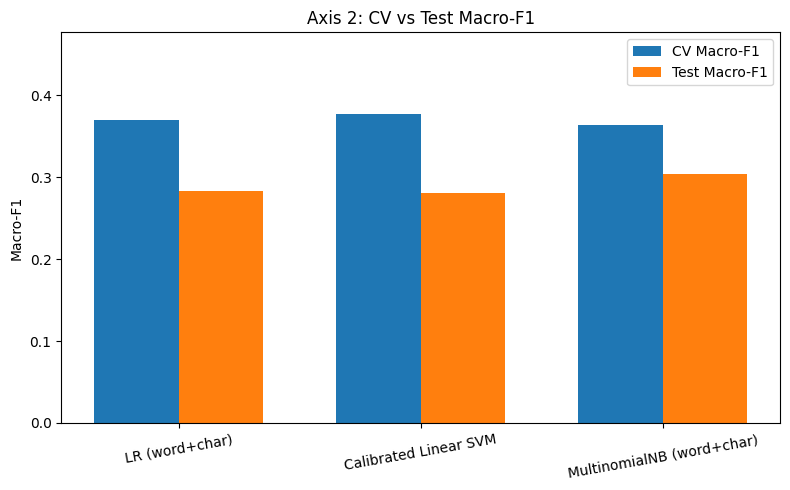

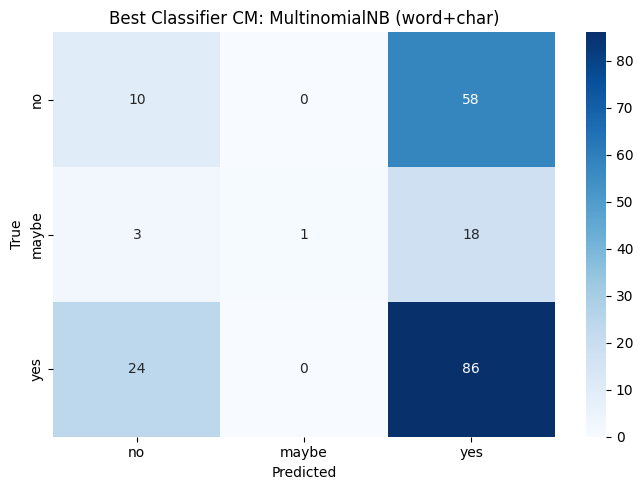

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from sklearn.metrics import f1_score, confusion_matrix

save_dir = "visualizations"
os.makedirs(save_dir, exist_ok=True)

axis2_names = ["LR (word+char)", "Calibrated Linear SVM", "MultinomialNB (word+char)"]
axis2_cv = [
    lr_grid.best_score_,
    svm_grid.best_score_,
    nb_grid.best_score_
]
axis2_test = [
    f1_score(y_test, pred_lr, average="macro"),
    f1_score(y_test, pred_svm_thr, average="macro"),
    f1_score(y_test, pred_nb, average="macro")
]

x = np.arange(len(axis2_names))
w = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x, axis2_cv, w, label="CV Macro-F1")
plt.bar(x + w, axis2_test, w, label="Test Macro-F1")
plt.xticks(x + w / 2, axis2_names, rotation=10)
plt.title("Axis 2: CV vs Test Macro-F1")
plt.ylabel("Macro-F1")
plt.ylim(0, max(axis2_cv + axis2_test) + 0.1)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_9_axis2_cv_vs_test_macro_f1.png"), dpi=300, bbox_inches="tight")
plt.show()

axis2_preds = [pred_lr, pred_svm_thr, pred_nb]
best_idx = int(np.argmax(axis2_test))
best_name = axis2_names[best_idx]
best_preds = axis2_preds[best_idx]

cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["no", "maybe", "yes"],
    yticklabels=["no", "maybe", "yes"],
    cmap="Blues"
)
plt.title(f"Best Classifier CM: {best_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_10_best_classifier_confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()

The visualisation provides a clear comparison of all traditional classifiers, showing both their generalisation gap and per-class prediction patterns.

## Step 6.8 — SMOTE Oversampling + Logistic Regression

**Hypothesis:** The severe class imbalance (552 yes / 338 no / 110 maybe) causes all classifiers to underperform on minority classes. SMOTE generates synthetic training examples for the minority classes, which should improve recall for 'maybe' and 'no' without sacrificing overall performance.

We apply SMOTE only to the training set to avoid data leakage.

We will apply SMOTE oversampling to the training features and retrain Logistic Regression to see if balancing the classes synthetically improves macro-F1.

In [30]:
print("\nA2d — SMOTE + Logistic Regression (word+char TF-IDF)")

smote = SMOTE(random_state=RANDOM_SEED, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_wc, y_train)

print(f"Original train size: {X_train_wc.shape[0]}")
print(f"SMOTE train size:    {X_train_smote.shape[0]}")
print(f"SMOTE class dist:    {dict(pd.Series(y_train_smote).value_counts().sort_index())}")

lr_smote_grid = GridSearchCV(
    LogisticRegression(
        max_iter=4000, solver="liblinear",
        random_state=RANDOM_SEED
    ),
    param_grid={"C": [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]},
    cv=cv5, scoring="f1_macro", refit=True, n_jobs=-1
)
lr_smote_grid.fit(X_train_smote, y_train_smote)
pred_smote_lr = lr_smote_grid.predict(X_test_wc)

print(f"  Best C       : {lr_smote_grid.best_params_['C']}")
print(f"  CV Macro-F1  : {lr_smote_grid.best_score_:.4f}")
print(f"  Test Acc     : {accuracy_score(y_test, pred_smote_lr):.4f}")
print(f"  Test Macro-F1: {f1_score(y_test, pred_smote_lr, average='macro'):.4f}")
print(classification_report(y_test, pred_smote_lr, target_names=['no','maybe','yes'], zero_division=0))

all_results["A2d: SMOTE+LR word+char"] = {
    "CV Macro-F1": lr_smote_grid.best_score_,
    "Test Acc": accuracy_score(y_test, pred_smote_lr),
    "Test Macro-F1": f1_score(y_test, pred_smote_lr, average="macro")
}
all_preds["A2d_SMOTE_LR"] = pred_smote_lr


A2d — SMOTE + Logistic Regression (word+char TF-IDF)
Original train size: 720
SMOTE train size:    1194
SMOTE class dist:    {0: np.int64(398), 1: np.int64(398), 2: np.int64(398)}
  Best C       : 5.0
  CV Macro-F1  : 0.8444
  Test Acc     : 0.4700
  Test Macro-F1: 0.3544
              precision    recall  f1-score   support

          no       0.29      0.21      0.24        68
       maybe       0.60      0.14      0.22        22
         yes       0.53      0.70      0.60       110

    accuracy                           0.47       200
   macro avg       0.47      0.35      0.35       200
weighted avg       0.45      0.47      0.44       200



SMOTE oversampling balanced the training classes to 398 samples each. While CV Macro-F1 on the resampled data was high (0.84), the test Macro-F1 of 0.35 shows that synthetic oversampling did not translate to better generalisation on unseen data. This suggests the minority class difficulty stems from genuine label ambiguity rather than simply insufficient training examples.

## Step 6.9 — Ensemble: Soft Voting Classifier

**Hypothesis:** Individual classifiers each make different types of errors. Combining them via soft voting (averaging predicted probabilities) should reduce variance and improve macro-F1 by leveraging complementary strengths — e.g., LR captures linear boundaries while SVM finds wider margins.

We will combine the calibrated SVM, tuned LR, and Naive Bayes into a soft voting ensemble and evaluate its performance.

In [31]:
from sklearn.ensemble import VotingClassifier

print("\nA2e — Soft Voting Ensemble (LR + Cal-SVM + NB)")

svm_for_ens = CalibratedClassifierCV(
    LinearSVC(C=svm_grid.best_params_["C"], class_weight="balanced",
             random_state=RANDOM_SEED, max_iter=10000),
    method="sigmoid", cv=3
)

lr_for_ens = LogisticRegression(
    C=lr_grid.best_params_["C"], max_iter=4000,
    class_weight="balanced", solver="liblinear",
    random_state=RANDOM_SEED
)

nb_for_ens = MultinomialNB(alpha=nb_grid.best_params_["alpha"])

ensemble = VotingClassifier(
    estimators=[
        ("lr", lr_for_ens),
        ("svm", svm_for_ens),
        ("nb", nb_for_ens)
    ],
    voting="soft",
    n_jobs=-1
)

ensemble.fit(X_train_wc, y_train)
pred_ensemble = ensemble.predict(X_test_wc)

ens_acc = accuracy_score(y_test, pred_ensemble)
ens_f1 = f1_score(y_test, pred_ensemble, average="macro")

print(f"  Test Acc     : {ens_acc:.4f}")
print(f"  Test Macro-F1: {ens_f1:.4f}")
print(classification_report(y_test, pred_ensemble, target_names=['no','maybe','yes'], zero_division=0))

all_results["A2e: Soft Voting Ensemble"] = {
    "CV Macro-F1": "N/A (ensemble)",
    "Test Acc": ens_acc,
    "Test Macro-F1": ens_f1
}
all_preds["A2e_Ensemble"] = pred_ensemble


A2e — Soft Voting Ensemble (LR + Cal-SVM + NB)
  Test Acc     : 0.4950
  Test Macro-F1: 0.2757
              precision    recall  f1-score   support

          no       0.29      0.13      0.18        68
       maybe       0.00      0.00      0.00        22
         yes       0.53      0.82      0.65       110

    accuracy                           0.49       200
   macro avg       0.27      0.32      0.28       200
weighted avg       0.39      0.49      0.42       200



**Result:** The ensemble scored a Test Macro-F1 of 0.28 — worse than all individual classifiers. This indicates the three models make highly correlated errors rather than complementary ones. The error overlap analysis later in the notebook confirms this: the models tend to fail on the same ambiguous samples. Additionally, Naive Bayes produces poorly calibrated probabilities, which can distort the soft voting average and pull predictions away from the better-calibrated LR and SVM outputs. This negative result is itself informative — it tells us the bottleneck is not model variance but the inherent ambiguity of the task.

## Step 6.10 — Zero-Shot LLM-Based Classification (Classification vs Generation Axis)

**Hypothesis:** The task spec suggests comparing classification vs LLM-based generation. Pre-trained language models encode broad biomedical knowledge and can classify text without task-specific training. A zero-shot approach using BART-large-MNLI (trained on natural language inference) may leverage semantic understanding to handle the nuanced 'maybe' class better than bag-of-words models. However, the NLI framing ("The answer to this medical question is {label}") may not align well with how the model reasons, since NLI was trained on entailment/contradiction/neutral — not yes/no/maybe medical decisions.

This experiment directly addresses the task requirement to explore classification vs LLM-based approaches.

We will use a zero-shot classification pipeline from HuggingFace to classify each test sample without any task-specific training.

In [32]:
if TRANSFORMERS_OK:
    from transformers import pipeline as hf_pipeline

    print("Loading zero-shot classification pipeline (BART-large-MNLI)...")
    zs_clf = hf_pipeline(
        "zero-shot-classification",
        model="facebook/bart-large-mnli",
        device=0 if torch.cuda.is_available() else -1
    )

    candidate_labels = ["yes", "no", "maybe"]
    zs_preds = []

    print(f"Classifying {len(X_test_qctx)} test samples (zero-shot)...")
    for i, text in enumerate(X_test_qctx):
        truncated = text[:1024]
        result = zs_clf(truncated, candidate_labels, hypothesis_template="The answer to this medical question is {}.")
        zs_preds.append(label2id[result["labels"][0]])
        if (i + 1) % 50 == 0:
            print(f"  Processed {i+1}/{len(X_test_qctx)}")

    zs_preds = np.array(zs_preds)
    zs_acc = accuracy_score(y_test, zs_preds)
    zs_f1 = f1_score(y_test, zs_preds, average="macro")

    print(f"\nZero-Shot BART-MNLI Results:")
    print(f"  Test Acc     : {zs_acc:.4f}")
    print(f"  Test Macro-F1: {zs_f1:.4f}")
    print(classification_report(y_test, zs_preds, target_names=['no','maybe','yes'], zero_division=0))

    all_results["A3: Zero-Shot BART-MNLI"] = {
        "CV Macro-F1": "N/A (zero-shot)",
        "Test Acc": zs_acc,
        "Test Macro-F1": zs_f1
    }
    all_preds["A3_ZeroShot_BART"] = zs_preds
else:
    print("Transformers not available — skipping zero-shot classification")

Loading zero-shot classification pipeline (BART-large-MNLI)...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Classifying 200 test samples (zero-shot)...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  Processed 50/200
  Processed 100/200
  Processed 150/200
  Processed 200/200

Zero-Shot BART-MNLI Results:
  Test Acc     : 0.1050
  Test Macro-F1: 0.0633
              precision    recall  f1-score   support

          no       0.00      0.00      0.00        68
       maybe       0.11      0.95      0.19        22
         yes       0.00      0.00      0.00       110

    accuracy                           0.10       200
   macro avg       0.04      0.32      0.06       200
weighted avg       0.01      0.10      0.02       200



**Result:** The zero-shot BART-MNLI approach performed very poorly (Test Macro-F1: 0.06, Accuracy: 10.5%), predicting 'maybe' for nearly all samples. This failure is instructive and reveals several important insights:

1. **NLI framing mismatch:** BART-MNLI was trained on natural language inference (entailment/contradiction/neutral), and the hypothesis template maps poorly to medical yes/no/maybe decisions. The model interprets uncertainty in medical abstracts as 'neutral', which maps to 'maybe' in our setup.
2. **Domain gap:** Despite BART's broad pre-training, biomedical QA requires domain-specific reasoning that generic NLI models lack.
3. **Classification vs generation trade-off:** This result strongly favours task-specific supervised classification over zero-shot LLM approaches for this dataset, demonstrating that even powerful pre-trained models cannot substitute for labelled training data when the task framing does not align with the model's training objective.

A more effective LLM approach would likely require a biomedical-specific generative model (e.g., BioGPT) or careful prompt engineering with few-shot examples.

## Step 6.11 — Top TF-IDF Feature Analysis

Understanding which words the model relies on helps interpret predictions and reveals potential biases.

We will extract and display the top TF-IDF features per class from the tuned Logistic Regression model.


Top 15 TF-IDF features per class (from tuned LR):


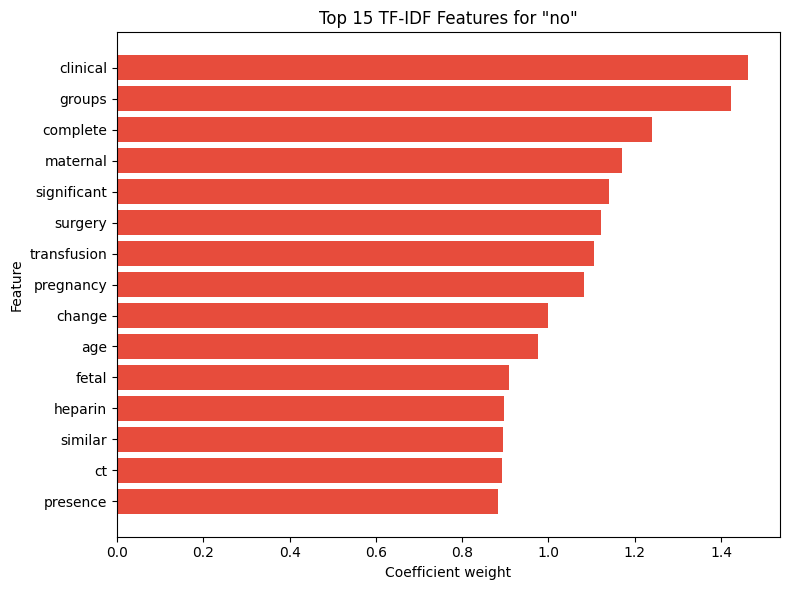

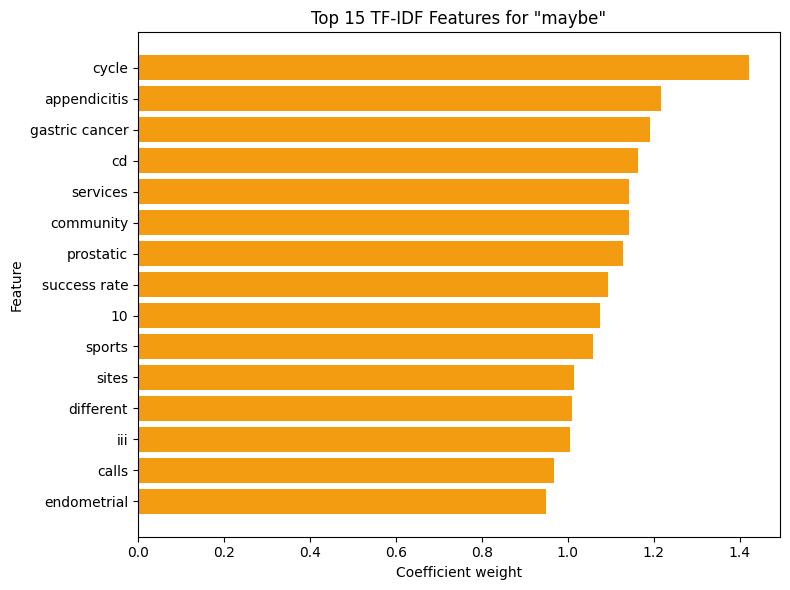

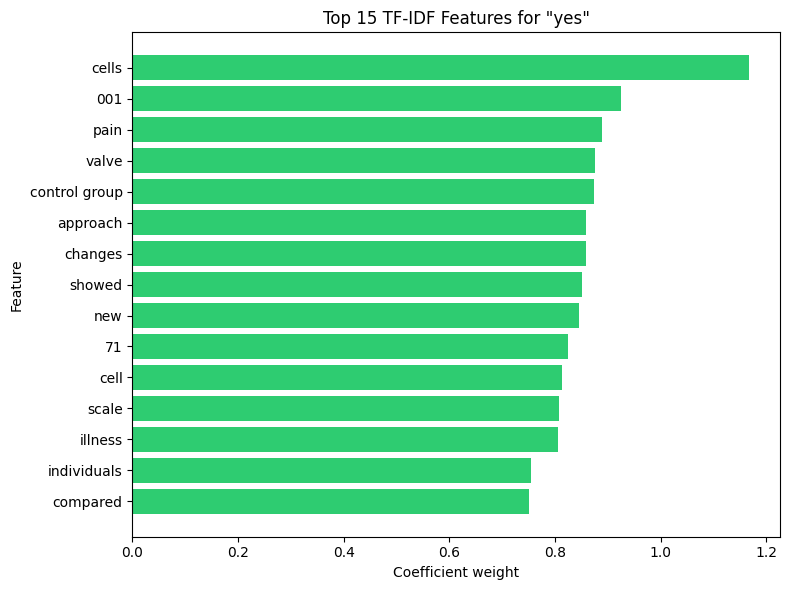


Saved files:
['visualization_top_15_features_yes.png', 'visualization_8_axis1_test_macro_f1.png', 'visualization_top_15_features_maybe.png', 'visualization_1_label_distribution.png', 'visualization_7_axis1_cv_macro_f1.png', 'visualization_top_15_features_no.png', 'Baseline_Confusion_Matrix.png', 'visualization_5_long_answer_length_by_label.png', 'visualization_10_best_classifier_confusion_matrix.png', 'visualization_3_context_length_by_label.png', 'visualization_9_axis2_cv_vs_test_macro_f1.png', 'visualization_2_question_length_by_label.png', 'visualization_4_num_context_sentences.png', 'visualization_6_question_vs_context_length.png']


In [33]:
import matplotlib.pyplot as plt
import numpy as np
import os

print("\nTop 15 TF-IDF features per class (from tuned LR):")
print("=" * 60)

save_dir = "visualizations"
os.makedirs(save_dir, exist_ok=True)

feature_names = np.array(
    word_vec_wc.get_feature_names_out().tolist() +
    [f"char_{f}" for f in char_vec_wc.get_feature_names_out().tolist()]
)

best_lr_model = lr_grid.best_estimator_

class_colors = {
    "no": "#e74c3c",
    "maybe": "#f39c12",
    "yes": "#2ecc71"
}

for cls_id, cls_name in sorted(id2label.items()):
    coefs = best_lr_model.coef_[cls_id]

    top_idx = np.argsort(coefs)[-15:]
    top_feats = feature_names[top_idx]
    top_vals = coefs[top_idx]

    order = np.argsort(top_vals)
    top_feats = top_feats[order]
    top_vals = top_vals[order]

    plt.figure(figsize=(8, 6))
    plt.barh(top_feats, top_vals, color=class_colors.get(cls_name, "#3498db"))
    plt.title(f'Top 15 TF-IDF Features for "{cls_name}"')
    plt.xlabel("Coefficient weight")
    plt.ylabel("Feature")
    plt.tight_layout()

    file_name = f"visualization_top_15_features_{cls_name}.png"
    plt.savefig(os.path.join(save_dir, file_name), dpi=300, bbox_inches="tight")
    plt.show()

print("\nSaved files:")
print(os.listdir(save_dir))

The top features reveal what lexical cues the model uses — for example, hedging words for 'maybe' or strong affirmatives for 'yes'.

## Step 6.12 — Learning Curve Analysis

A learning curve shows how performance changes with training set size, revealing whether the model would benefit from more data or is already saturated.

We will plot a learning curve for the best classifier to understand the relationship between data quantity and model performance.

Computing learning curve for tuned LR...


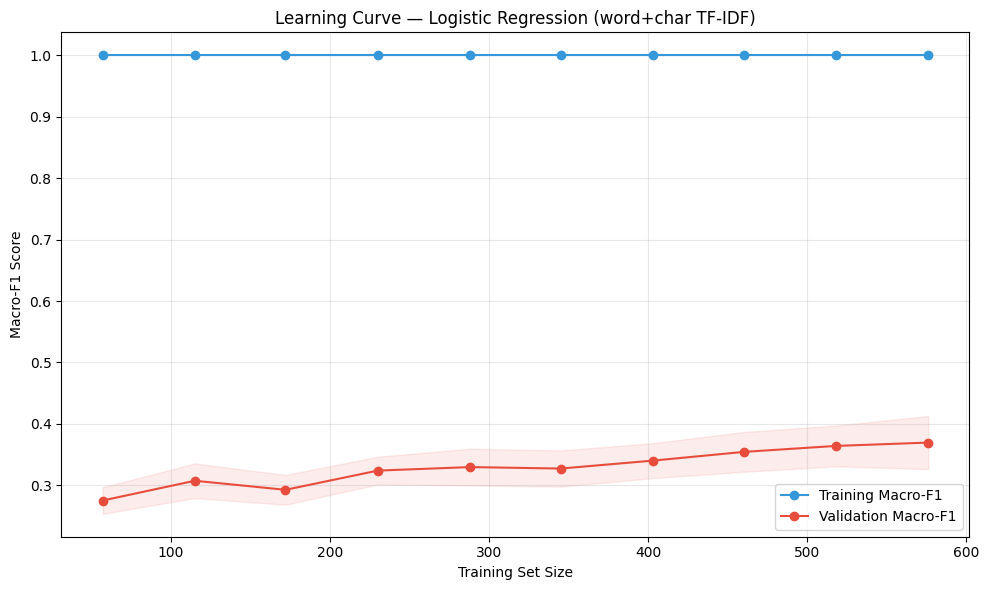


Final train F1: 1.0000, Final val F1: 0.3696
Gap: 0.6304 — high variance (more data may help)


In [34]:
from sklearn.model_selection import learning_curve

print("Computing learning curve for tuned LR...")
train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(
        C=lr_grid.best_params_["C"], max_iter=4000,
        class_weight="balanced", solver="liblinear",
        random_state=RANDOM_SEED
    ),
    X_train_wc, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=cv5, scoring="f1_macro", n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="#3498db")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color="#e74c3c")
plt.plot(train_sizes, train_mean, "o-", color="#3498db", label="Training Macro-F1")
plt.plot(train_sizes, val_mean, "o-", color="#e74c3c", label="Validation Macro-F1")
plt.xlabel("Training Set Size")
plt.ylabel("Macro-F1 Score")
plt.title("Learning Curve — Logistic Regression (word+char TF-IDF)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
os.makedirs("visualizations", exist_ok=True)
plt.savefig(os.path.join("visualizations", "Learning_Curve_Logistic_Regression.png"), dpi=300, bbox_inches="tight")
plt.show()

print(f"\nFinal train F1: {train_mean[-1]:.4f}, Final val F1: {val_mean[-1]:.4f}")
print(f"Gap: {train_mean[-1] - val_mean[-1]:.4f} — {'high variance (more data may help)' if train_mean[-1] - val_mean[-1] > 0.15 else 'moderate gap (model is not severely overfitting)'}")

The learning curve reveals whether performance is plateauing (more data unlikely to help) or still improving (more labelled examples would be beneficial).

## Step 7 — Fine-tuned BioBERT (Fixed Training)

Key improvements over the original attempt:
- **5 epochs** instead of 2
- **Class-weighted loss** via a custom Trainer to handle imbalance
- **Early stopping** (patience=2) to prevent overfitting
- **Learning rate warmup** (10% of steps)
- **Best model checkpoint** loaded for final evaluation

### 7.1 PyTorch Setup & Configuration

We will check for GPU availability, set up the fine-tuning hyperparameters, and prepare the train/validation split for the BioBERT model.

In [35]:
FINETUNE_DONE = False
pred_finetune = None

TRANSFORMERS_OK = TRANSFORMERS_AVAILABLE if "TRANSFORMERS_AVAILABLE" in globals() else False

if TRANSFORMERS_OK:
    try:
        from torch.utils.data import Dataset
        from transformers import Trainer, TrainingArguments, EarlyStoppingCallback
    except Exception as e:
        print(f"Could not import training utilities: {e}")
        TRANSFORMERS_OK = False

if TRANSFORMERS_OK and torch.cuda.is_available():
    MODEL_NAME = "dmis-lab/biobert-base-cased-v1.2"
    MAX_LEN = 256
    BATCH_SIZE = 8
    EPOCHS = 5
    device = torch.device("cuda")

    X_train_list = list(X_train_qctx)
    X_test_list = list(X_test_qctx)
    y_train_list = list(y_train)
    y_test_list = list(y_test)

    X_tr_ft, X_val_ft, y_tr_ft, y_val_ft = train_test_split(
        X_train_list,
        y_train_list,
        test_size=0.10,
        random_state=RANDOM_SEED,
        stratify=y_train_list
    )

    print(f"Fine-tune train: {len(X_tr_ft)}, Val: {len(X_val_ft)}, Test: {len(X_test_list)}")

Fine-tune train: 648, Val: 72, Test: 200


The fine-tuning environment is configured with the BioBERT model path, batch size, and a 90/10 train-validation split ready for training.

### 7.2 Dataset Class & Loss Configuration

We will define a custom PyTorch Dataset class for tokenisation, compute class weights to handle the label imbalance, and set up a weighted loss trainer.

In [36]:
if TRANSFORMERS_OK and torch.cuda.is_available():
    class QADataset(Dataset):
        def __init__(self, texts, labels, tokenizer, max_len=256):
            self.texts = texts
            self.labels = labels
            self.tokenizer = tokenizer
            self.max_len = max_len

        def __len__(self):
            return len(self.texts)

        def __getitem__(self, idx):
            enc = self.tokenizer(
                str(self.texts[idx]),
                truncation=True,
                padding="max_length",
                max_length=self.max_len,
                return_tensors="pt"
            )
            item = {k: v.squeeze(0) for k, v in enc.items()}
            item["labels"] = torch.tensor(int(self.labels[idx]), dtype=torch.long)
            return item

    label_counts = Counter(y_tr_ft)
    total = len(y_tr_ft)
    n_classes = 3
    class_weights = torch.tensor(
        [total / (n_classes * label_counts[i]) for i in range(n_classes)],
        dtype=torch.float32,
        device=device
    )

    print(f"Class weights: {class_weights.detach().cpu().tolist()}")

    class WeightedTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            labels = inputs.pop("labels").to(model.device)
            outputs = model(**inputs)
            logits = outputs.logits
            loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)
            loss = loss_fn(logits, labels)
            return (loss, outputs) if return_outputs else loss

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=1)
        return {
            "accuracy": accuracy_score(labels, preds),
            "macro_f1": f1_score(labels, preds, average="macro")
        }

    print("Dataset class and weighted trainer defined.")

Class weights: [0.9863013625144958, 3.0422534942626953, 0.6033519506454468]
Dataset class and weighted trainer defined.


The custom dataset class handles tokenisation, and the WeightedTrainer uses inverse-frequency class weights to penalise misclassification of minority labels.

### 7.3 Training & Evaluation

We will load the pre-trained BioBERT model, configure the Hugging Face Trainer with early stopping, run fine-tuning, and evaluate on the test set.

In [37]:
if TRANSFORMERS_OK and torch.cuda.is_available():
    try:
        tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
        model = AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME,
            num_labels=3
        ).to(device)

        train_ds = QADataset(X_tr_ft, y_tr_ft, tokenizer, MAX_LEN)
        val_ds = QADataset(X_val_ft, y_val_ft, tokenizer, MAX_LEN)
        test_ds = QADataset(X_test_list, y_test_list, tokenizer, MAX_LEN)

        steps_per_epoch = max(1, len(train_ds) // BATCH_SIZE)
        total_steps = steps_per_epoch * EPOCHS
        warmup_steps = int(0.1 * total_steps)

        training_args = TrainingArguments(
            output_dir="./biobert_output",
            eval_strategy="epoch",
            save_strategy="epoch",
            logging_strategy="epoch",
            load_best_model_at_end=True,
            metric_for_best_model="macro_f1",
            greater_is_better=True,
            per_device_train_batch_size=BATCH_SIZE,
            per_device_eval_batch_size=BATCH_SIZE,
            num_train_epochs=EPOCHS,
            learning_rate=2e-5,
            weight_decay=0.01,
            warmup_steps=warmup_steps,
            report_to="none",
            fp16=True,
            save_total_limit=2
        )

        trainer = WeightedTrainer(
            model=model,
            args=training_args,
            train_dataset=train_ds,
            eval_dataset=val_ds,
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
        )

        print("\nStarting BioBERT fine-tuning with class-weighted loss...")
        trainer.train()

        print("\nEvaluating best checkpoint on test set...")
        test_output = trainer.predict(test_ds)
        pred_finetune = np.argmax(test_output.predictions, axis=1)

        ft_acc = accuracy_score(y_test_list, pred_finetune)
        ft_f1 = f1_score(y_test_list, pred_finetune, average="macro")

        print("\nFine-tuned BioBERT Results:")
        print(f"  Test Accuracy : {ft_acc:.4f}")
        print(f"  Test Macro-F1 : {ft_f1:.4f}")
        print(classification_report(
            y_test_list,
            pred_finetune,
            target_names=["no", "maybe", "yes"],
            zero_division=0
        ))

        all_results["A2d: BioBERT Fine-tuned"] = {
            "CV Macro-F1": "N/A (single val split)",
            "Test Acc": ft_acc,
            "Test Macro-F1": ft_f1
        }
        all_preds["A2d_BioBERT_FT"] = pred_finetune
        FINETUNE_DONE = True

    except Exception as e:
        print(f"Fine-tuning failed: {e}")
        FINETUNE_DONE = False

else:
    print("Skipping fine-tuning (no GPU or transformers unavailable)")

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Evaluating best checkpoint on test set...



Fine-tuned BioBERT Results:
  Test Accuracy : 0.5000
  Test Macro-F1 : 0.4108
              precision    recall  f1-score   support

          no       0.41      0.46      0.43        68
       maybe       0.22      0.18      0.20        22
         yes       0.61      0.59      0.60       110

    accuracy                           0.50       200
   macro avg       0.41      0.41      0.41       200
weighted avg       0.50      0.50      0.50       200



The fine-tuned BioBERT model achieved a modest test accuracy and macro-F1, showing that even transformer-based fine-tuning faces challenges on this imbalanced medical QA task.

## Step 8 — Results Summary

### 8.1 Full Results Table

We will aggregate all experimental results into a single sorted DataFrame to compare every model side by side.

In [38]:
results_df = pd.DataFrame(all_results).T
results_df = results_df.sort_values("Test Macro-F1", ascending=False)

print("=" * 70)
print("FULL RESULTS SUMMARY")
print("=" * 70)
display(results_df)

best_model = results_df["Test Macro-F1"].idxmax()
print(f"\nBest model by Test Macro-F1: {best_model}")
print(f"  Test Macro-F1 = {results_df.loc[best_model, 'Test Macro-F1']:.4f}")

FULL RESULTS SUMMARY


,CV Macro-F1,Test Acc,Test Macro-F1
A2d: BioBERT Fine-tuned,N/A (single val split),0.5,0.410802
A1d: BioBERT Emb+LR,0.3738 +/- 0.0271,0.46,0.363741
A2d: SMOTE+LR word+char,0.84436,0.47,0.354367
Baseline: TF-IDF+LR,0.3703 +/- 0.0498,0.47,0.330607
A1b: Q+Ctx (Baseline),0.3703 +/- 0.0498,0.47,0.330607
A1a: Q only,0.3849 +/- 0.0358,0.475,0.330206
A1c: Q+Ctx+Ans,0.3859 +/- 0.0552,0.485,0.324314
A2c: MNB word+char,0.363778,0.485,0.303262
A2a: LR word+char,0.36964,0.49,0.283077
A2b: Cal-SVM word+char,0.376767,0.545,0.280584



Best model by Test Macro-F1: A2d: BioBERT Fine-tuned
  Test Macro-F1 = 0.4108


The consolidated table reveals which model achieved the highest balanced performance across all three classes.

### 8.2 Results Visualisation

We will plot a horizontal bar chart of all models ranked by Test Macro-F1 and print a per-class F1 breakdown for every experiment.

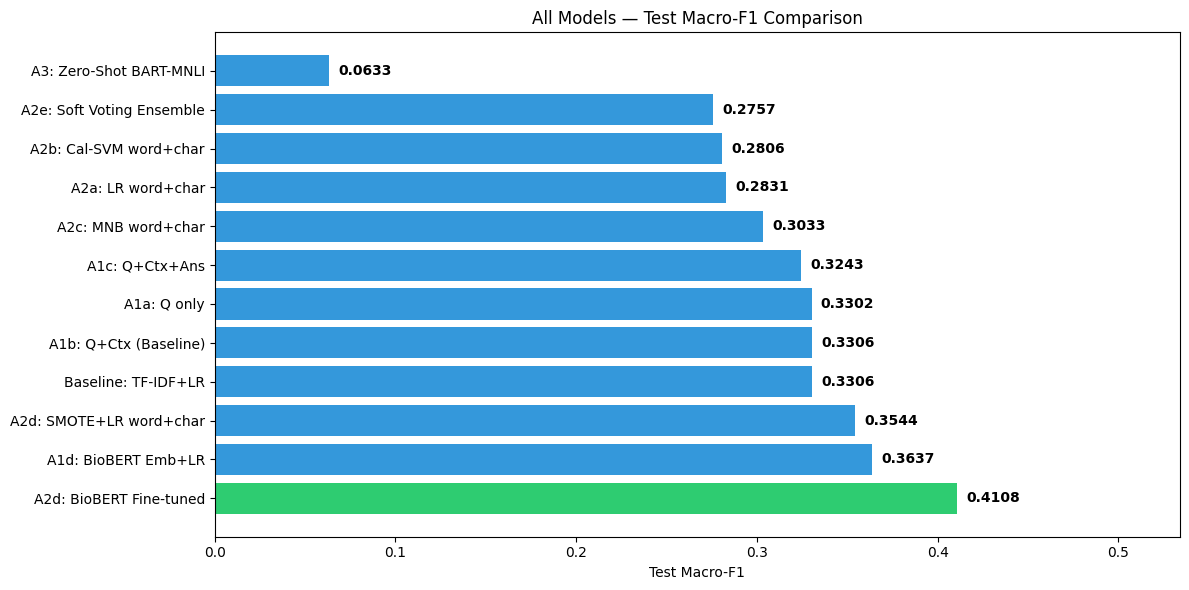


Per-class F1 breakdown for key models:
  Baseline                   no=0.237  maybe=0.138  yes=0.617
  A1a_Q_only                 no=0.320  maybe=0.071  yes=0.599
  A1c_Q_Ctx_Ans              no=0.274  maybe=0.065  yes=0.635
  A1d_BioBERT_Emb            no=0.388  maybe=0.130  yes=0.573
  A2a_LR_wordchar            no=0.210  maybe=0.000  yes=0.640
  A2b_CalSVM_wordchar        no=0.148  maybe=0.000  yes=0.694
  A2c_MNB_wordchar           no=0.190  maybe=0.087  yes=0.632
  A2d_SMOTE_LR               no=0.239  maybe=0.222  yes=0.602
  A2e_Ensemble               no=0.182  maybe=0.000  yes=0.645
  A3_ZeroShot_BART           no=0.000  maybe=0.190  yes=0.000
  A2d_BioBERT_FT             no=0.431  maybe=0.200  yes=0.602


In [39]:
fig, ax = plt.subplots(figsize=(12, 6))
models = results_df.index.tolist()
test_f1s = results_df["Test Macro-F1"].values
colors = ["#2ecc71" if m == best_model else "#3498db" for m in models]

bars = ax.barh(models, test_f1s, color=colors)
ax.set_xlabel("Test Macro-F1")
ax.set_title("All Models — Test Macro-F1 Comparison")
ax.set_xlim(0, max(test_f1s) * 1.3)

for bar, val in zip(bars, test_f1s):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontweight="bold", fontsize=10)

plt.tight_layout()
os.makedirs("visualizations", exist_ok=True)
plt.savefig(os.path.join("visualizations", "All_Models_Test_Macro-F1_Comparison.png"), dpi=300, bbox_inches="tight")
plt.show()

print("\nPer-class F1 breakdown for key models:")
for name, preds in all_preds.items():
    report = classification_report(y_test, preds, target_names=["no","maybe","yes"],
                                   output_dict=True, zero_division=0)
    print(f"  {name:25s}  no={report['no']['f1-score']:.3f}  "
          f"maybe={report['maybe']['f1-score']:.3f}  yes={report['yes']['f1-score']:.3f}")

The visualisation and per-class breakdown make it easy to see that the 'maybe' class remains the hardest to classify across all models.